# Telco Customer Churn

Цель: предсказать уход клиента

Что делаем: обучаем несколько моделей и сравниваем результаты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('telco.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df["TotalCharges"].value_counts().head(10)


TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
45.3      7
19.55     7
20.15     6
20.25     6
Name: count, dtype: int64

# Обработка пропусков

In [9]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"].value_counts().head(10)

TotalCharges
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
19.55     7
45.3      7
19.45     6
20.25     6
20.15     6
Name: count, dtype: int64

In [10]:
df["TotalCharges"] = df["TotalCharges"].astype(float)


In [11]:
df["TotalCharges"].isnull().sum()


np.int64(11)

In [12]:
df = df.dropna(subset=["TotalCharges"])


# Churn to binary

In [13]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"].value_counts()
df = df.drop(columns=["customerID"])

# feature engineering

In [14]:
df["TotalCharges_log"] = np.log1p(df["TotalCharges"])

df["MonthlyCharges_tenure"] = df["MonthlyCharges"] * df["tenure"]

df["Senior_MonthlyCharges"] = df["SeniorCitizen"] * df["MonthlyCharges"]

eps = 1e-3
df["Tenure_per_Monthly"] = df["tenure"] / (df["MonthlyCharges"] + eps)

bins = [0, 12, 24, 48, 72]  # границы
labels = ["0-12", "12-24", "24-48", "48+"]  # названия групп

df["tenure_bin"] = pd.cut(df["tenure"], bins=bins, labels=labels, right=True, include_lowest=True)

freq = df["PaymentMethod"].value_counts(normalize=True)
df["PaymentMethod_freq"] = df["PaymentMethod"].map(freq)

# divide features

In [15]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

num_cols = X.select_dtypes(include=["int64", "float64", "float32"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


# Preprocessor for Lr

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [18]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# LR Model

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",   # важно при дисбалансе
        penalty="l2",
        C=1.0,
        solver="liblinear",        # хорошо работает с OHE и небольшими данными
    )),
])


In [20]:
model.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Metrics

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix
pred = model.predict(X_test)
proba_lg = model.predict_proba(X_test)[:, 1]
threshold = 0.4

y_pred_lg = (proba_lg >= threshold).astype(int)

print("=== threshold =", threshold, "===")
print(classification_report(y_test, y_pred_lg))
print("ROC AUC score:", roc_auc_score(y_test, proba_lg))



=== threshold = 0.4 ===
              precision    recall  f1-score   support

           0       0.93      0.62      0.75      1033
           1       0.46      0.87      0.60       374

    accuracy                           0.69      1407
   macro avg       0.69      0.75      0.67      1407
weighted avg       0.80      0.69      0.71      1407

ROC AUC score: 0.8396563148712798


# preprocessor for RF and XGB

In [22]:
preprocessor2 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)


# RF model

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor2),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [24]:
rf_model.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# RF metrics

In [44]:
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.59      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407

ROC-AUC: 0.8270819636487878


In [45]:
from sklearn.metrics import f1_score, recall_score, precision_score

thresholds = [i/100 for i in range(1, 100)]
best_f1 = 0
best_t = 0

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

for t in thresholds:
    preds = (y_proba_rf >= t).astype(int)
    score = f1_score(y_test, preds)
    if score > best_f1:
        best_f1 = score
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)


Best threshold: 0.44
Best F1: 0.6174334140435835


In [46]:
preds_rf = (y_proba_rf >= best_t).astype(int)
print(classification_report(y_test, preds_rf))


              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1033
           1       0.56      0.68      0.62       374

    accuracy                           0.78      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.79      0.78      0.78      1407



# RF plt

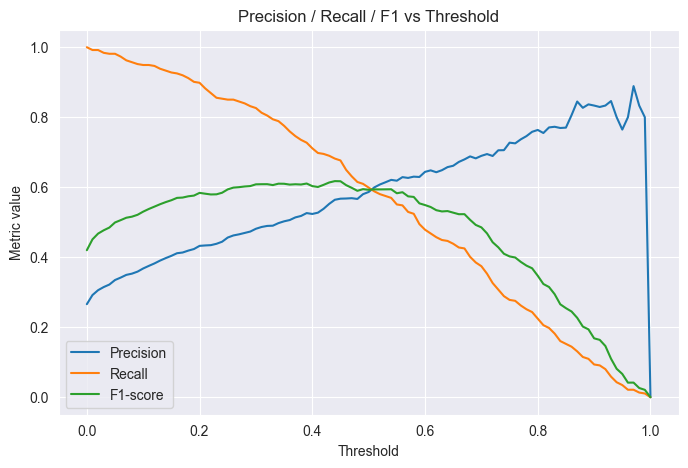

In [47]:
thresholds = np.linspace(0.0, 1.0, 101)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_thr = (y_proba_rf >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_thr, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_thr))
    f1s.append(f1_score(y_test, y_pred_thr))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1-score")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Precision / Recall / F1 vs Threshold")
plt.grid(True)
plt.legend()
plt.show()

# XGB model

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline(steps=[
    ("preprocess", preprocessor2),
    ("clf", XGBClassifier(
        n_estimators=300,       
        max_depth=4,            
        learning_rate=0.1,    
        subsample=0.9,          
        colsample_bytree=0.8,  
        eval_metric="logloss",  
        scale_pos_weight=2,  
        random_state=42,
        n_jobs=-1               # все ядра
    ))
])

In [30]:
xgb_model.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# XGB metrics

In [31]:
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1033
           1       0.54      0.68      0.60       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407

ROC-AUC: 0.821123512328455


In [60]:
from sklearn.metrics import f1_score, recall_score, precision_score

thresholds_xg = [i/100 for i in range(1, 100)]
best_f1_xg = 0
best_t_xg = 0

y_proba = xgb_model.predict_proba(X_test)[:, 1]

for t in thresholds_xg:
    preds_xg = (y_proba >= t).astype(int)
    score = f1_score(y_test, preds_xg)
    if score > best_f1_xg:
        best_f1_xg = score
        best_t_xg = t

print("Best threshold:", best_t_xg)
print("Best F1:", best_f1_xg)

Best threshold: 0.4
Best F1: 0.6132478632478633


In [61]:
preds_xg = (y_proba_xgb >= best_t_xg).astype(int)
print(classification_report(y_test, preds_xg))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.77      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



In [34]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("num:", num_cols)
print("cat:", cat_cols)


num: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalCharges_log', 'MonthlyCharges_tenure', 'Senior_MonthlyCharges', 'Tenure_per_Monthly', 'PaymentMethod_freq']
cat: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_bin']


# Catboost model

In [ ]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,           
    depth=6,                    
    learning_rate=0.1,         
    loss_function="Logloss",
    eval_metric="AUC",
    random_state=42,
    auto_class_weights="Balanced",  
    verbose=100               
)

In [ ]:
cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_cols,   
    eval_set=(X_test, y_test),
    use_best_model=True
)


0:	test: 0.8172940	best: 0.8172940 (0)	total: 64.6ms	remaining: 32.2s
100:	test: 0.8373151	best: 0.8395800 (56)	total: 419ms	remaining: 1.66s
200:	test: 0.8334546	best: 0.8395800 (56)	total: 913ms	remaining: 1.36s
300:	test: 0.8294503	best: 0.8395800 (56)	total: 1.35s	remaining: 891ms
400:	test: 0.8248314	best: 0.8395800 (56)	total: 1.73s	remaining: 427ms
499:	test: 0.8230868	best: 0.8395800 (56)	total: 2.11s	remaining: 0us

bestTest = 0.8395799577
bestIteration = 56

Shrink model to first 57 iterations.


# Catboost metrics

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_proba_cat = cat_model.predict_proba(X_test)[:, 1]
y_pred_cat = cat_model.predict(X_test)  

print(classification_report(y_test, y_pred_cat))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_cat))


              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.82      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.81      0.74      0.75      1407

ROC-AUC: 0.8395799576540993


In [48]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.0, 1.0, 101)
best_f1 = 0
best_t = 0.5

for t in thresholds:
    y_pred_thr = (y_proba_cat >= t).astype(int)
    score = f1_score(y_test, y_pred_thr)
    if score > best_f1:
        best_f1 = score
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

from sklearn.metrics import classification_report

preds_cat = (y_proba_cat >= best_t).astype(int)
print(classification_report(y_test, preds_cat))


Best threshold: 0.58
Best F1: 0.6375143843498274
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1033
           1       0.56      0.74      0.64       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.78      1407



Contract                 19.941419
Tenure_per_Monthly       14.672685
OnlineSecurity            9.260699
InternetService           8.559194
MonthlyCharges            6.430683
TechSupport               6.031263
MultipleLines             5.449341
PaymentMethod_freq        3.854163
OnlineBackup              3.779440
PaymentMethod             2.936301
tenure                    2.860032
TotalCharges              2.359369
MonthlyCharges_tenure     2.341661
StreamingMovies           2.295005
PaperlessBilling          2.123323
dtype: float64


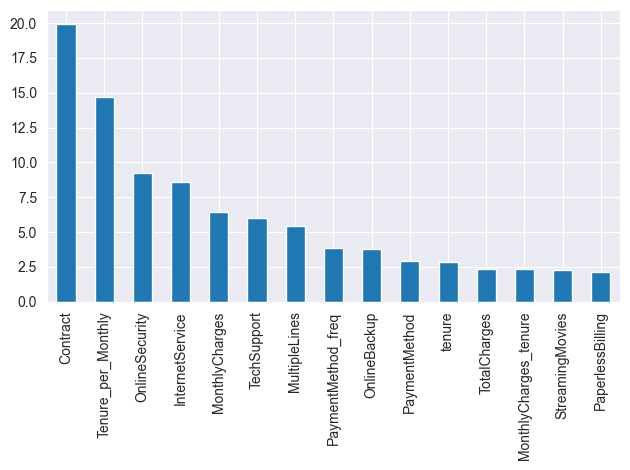

In [49]:


importances = cat_model.get_feature_importance()
feat_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print(feat_importance.head(15))

feat_importance.head(15).plot(kind="bar")
plt.tight_layout()
plt.show()


# precision_recall_curve for all models

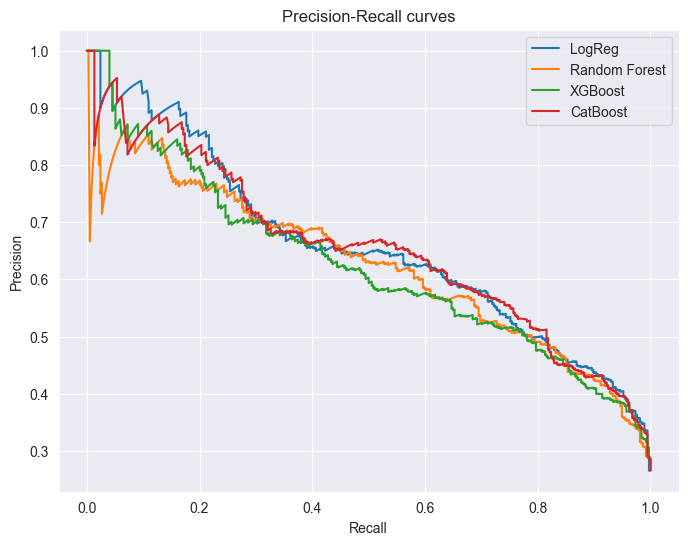

In [62]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Logistic Regression
prec_lr, rec_lr, _ = precision_recall_curve(y_test, proba_lg)
plt.plot(rec_lr, prec_lr, label="LogReg")

# Random Forest
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_proba_rf)
plt.plot(rec_rf, prec_rf, label="Random Forest")

# XGBoost
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)
plt.plot(rec_xgb, prec_xgb, label="XGBoost")

# CatBoost
prec_cat, rec_cat, _ = precision_recall_curve(y_test, y_proba_cat)
plt.plot(rec_cat, prec_cat, label="CatBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves")
plt.grid(True)
plt.legend()
plt.show()


# ROC curve for all models

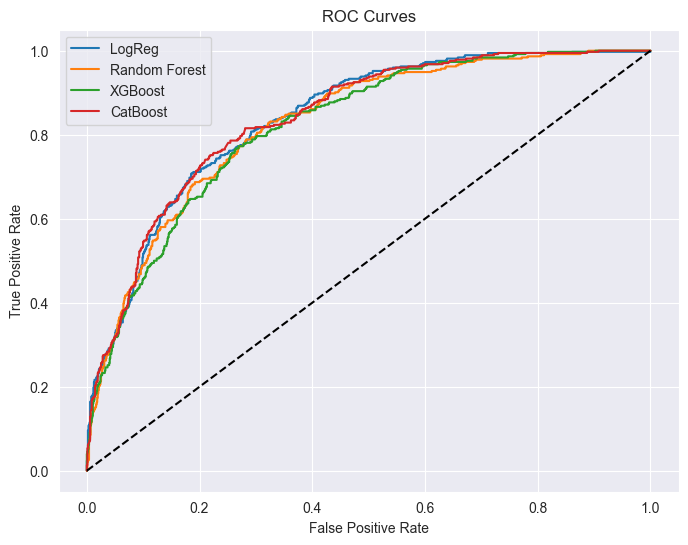

In [63]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lg)
plt.plot(fpr_lr, tpr_lr, label="LogReg")

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

fpr_cat, tpr_cat, _ = roc_curve(y_test, y_proba_cat)
plt.plot(fpr_cat, tpr_cat, label="CatBoost")

plt.plot([0,1],[0,1], "k--")  # диагональ
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.grid(True)
plt.legend()
plt.show()


# Итог: Catboost показал более стабильные результаты и выигрывает по основным метрикам засчет большого кол-ва категориальных признаков

# Эксперимент: RF with optuna

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 400)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    rf_clf = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ])

    scores = cross_val_score(
        rf_clf,
        X_train,
        y_train,
        cv=3,               # 3-fold CV, достаточно и быстро
        scoring="f1",       # можно "roc_auc", если хочешь
        n_jobs=-1
    )

    return scores.mean()    # Optuna будет максимизировать это значение


/Users/nikitadolgov/PycharmProjects/Python_ml/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# study Optuna

In [ ]:
study = optuna.create_study(direction="maximize")  
study.optimize(objective, n_trials=20)             

print("Лучшее значение F1 на CV:", study.best_value)
print("Лучшие параметры:", study.best_params)

[I 2025-11-15 14:22:26,394] A new study created in memory with name: no-name-2559f862-c782-4b33-8917-648e2de4c5f3
[I 2025-11-15 14:22:28,166] Trial 0 finished with value: 0.6364912006032876 and parameters: {'n_estimators': 237, 'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.6364912006032876.
[I 2025-11-15 14:22:29,370] Trial 1 finished with value: 0.6307340584349594 and parameters: {'n_estimators': 397, 'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.6364912006032876.
[I 2025-11-15 14:22:30,599] Trial 2 finished with value: 0.6352162019109263 and parameters: {'n_estimators': 342, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.6364912006032876.
[I 2025-11-15 14:22:30,769] Trial 3 finished with value: 0.6237081238457055 and parameters: {'n_estimators': 130, 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.

Лучшее значение F1 на CV: 0.6388260873315993
Лучшие параметры: {'n_estimators': 312, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 1}


In [54]:
best_params = study.best_params
best_params


{'n_estimators': 312,
 'max_depth': 7,
 'min_samples_split': 10,
 'min_samples_leaf': 1}

# RF model with optuna

In [55]:
best_rf_model = Pipeline(steps=[
    ("preprocess", preprocessor2),
    ("clf", RandomForestClassifier(
        **best_params,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

best_rf_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Metrics

In [56]:
y_proba_best = best_rf_model.predict_proba(X_test)[:, 1]
y_pred_best = best_rf_model.predict(X_test)

print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_best))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.79      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407

ROC-AUC: 0.8384061272137122
